# 01 · Data, Leakage-Free Preprocessing & EDA
**Deep Residual MLP for Diabetes Risk Prediction (CDC BRFSS 2015, PyTorch)**  
*Sections 1-5* · MSc Data Science project · Dr. Spoorthi H S

**In this notebook**
- Clinical motivation, objectives and the CDC BRFSS 2015 dataset (253,680 records, 21 features)
- Leakage-free pipeline: stratified 70/15/15 split → scaler fit on train → SMOTE on train only
- Class balance (13.9% positive), feature distributions by class, correlation and PCA views

> **How to use these notebooks.** The outputs below come from one complete run of the pipeline. Each part builds on objects created earlier (data splits, the trained model, chosen thresholds), so the part notebooks are for reading and review. To reproduce the results, run [`00_full_pipeline_run_all.ipynb`](00_full_pipeline_run_all.ipynb) top to bottom.

[Residual MLP & Depth × Width Ablation →](02_model_and_depth_width_ablation.ipynb)

---

#  Deep Residual MLP for Diabetes Risk Prediction
## A Hyperparameter Study on Depth, Width, and Imbalance Handling Using CDC BRFSS 2015
---

> **Dataset:** CDC Behavioral Risk Factor Surveillance System 2015 — 253,680 real government survey records  
> **Task:** Binary Classification — Diabetic/Pre-diabetic (1) vs Non-Diabetic (0)  
> **Framework:** PyTorch — Pure Deep Learning / MLP (No SVM, No Random Forest, No Boosted Trees)  

---

| Attribute | Detail |
|---|---|
| **Level** |  Deep Learning Research |
| **Core Fix** | Triple-defence imbalance strategy: SMOTE + Focal Loss + Optimal Threshold |
| **Key Visuals** | Training / Validation / Test curves on every plot — no ambiguity |
| **Result** | Test **AUC 0.9015**, Brier 0.0937, sensitivity **0.814** at the screening threshold, val–test AUC gap 0.0008 |

##  Table of Contents
1. [Introduction & Objective](#sec1)  
2. [Dataset Description](#sec2)  
3. [Environment Setup](#sec3)  
4. [Leakage-Free Preprocessing & SMOTE](#sec4)  
5. [Exploratory Data Analysis & Clinical Insights](#sec5)  
6. [Model Architecture — Clinical Deep MLP](#sec6)  
7. [Depth & Width Ablation Study](#sec7)  
8. [Full Training Pipeline with Live Curves](#sec8)  
9. [Training / Validation / Test Curve Dashboard](#sec9)  
10. [Threshold Optimisation for Clinical Use](#sec10)  
11. [Comprehensive Evaluation & Metrics](#sec11)  
12. [Explainability — SHAP & Integrated Gradients](#sec12)  
13. [Val vs Test Consistency Analysis](#sec13)  
14. [Regularisation Ablation Study](#sec14)  
15. [Limitations & Future Work](#sec15)  
16. [Conclusion & References](#sec16)  


---
## 1. Introduction & Objective <a id='sec1'></a>

### 1.1 Clinical Background

**Diabetes mellitus** affects over 537 million adults globally (IDF, 2021). The CDC estimates 38.4 million Americans have diabetes and 98.2 million are pre-diabetic — most **undiagnosed**. Early identification is transformative: lifestyle interventions in pre-diabetic individuals reduce progression by **58%** (Diabetes Prevention Program, NEJM 2002).

### 1.2 The Core Problem — Class Imbalance in Clinical AI

The BRFSS dataset has only **~13.9% positive cases**. This is a critical failure mode that v1 of this notebook suffered from:

| Failure Mode | Effect | Fix |
|---|---|---|
| BCE loss on imbalanced data | Model ignores minority class | Focal Loss (γ=2) |
| Default 0.5 threshold | Low sensitivity for diabetics | Sensitivity-targeted threshold |
| No oversampling | Model never sees enough positives | SMOTE on training set only |
| Scaler fitted on full data | Data leakage → inflated val metrics | Fit scaler on train split only |

### 1.3 Research Objectives and Outcome

| Objective | Target | Achieved (test set) | Status |
|---|---|---|---|
| Discrimination | AUC-ROC ≥ 0.95 | 0.9015 | Not met — limited by the 21 survey features |
| Diabetic class F1 | ≥ 0.80 | 0.6160 (F1-optimal threshold) | Not met — feature ceiling |
| Sensitivity (recall of positives) | ≥ 0.80 | 0.8140 (screening threshold) | Met |
| Val–Test AUC consistency | Gap < 0.02 | 0.0008 | Met |
| Calibration | Brier Score < 0.10 | 0.0937 | Met |

---
## 2. Dataset Description <a id='sec2'></a>

- **Source:** CDC BRFSS 2015 — curated by Alex Teboul  
- **Kaggle:** https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset  
- **Records:** 253,680 | **Features:** 21 | **Missing Values:** None

| # | Feature | Type | Clinical Meaning |
|---|---|---|---|
| 1 | `HighBP` | Binary | Hypertension diagnosed |
| 2 | `HighChol` | Binary | High cholesterol diagnosed |
| 3 | `CholCheck` | Binary | Cholesterol checked (5 yr) |
| 4 | `BMI` | Integer | Body Mass Index |
| 5 | `Smoker` | Binary | ≥100 cigarettes lifetime |
| 6 | `Stroke` | Binary | Stroke history |
| 7 | `HeartDiseaseorAttack` | Binary | CHD / MI history |
| 8 | `PhysActivity` | Binary | Exercise (30 days) |
| 9–10 | `Fruits`, `Veggies` | Binary | Daily servings |
| 11 | `HvyAlcoholConsump` | Binary | Heavy alcohol use |
| 12–13 | `AnyHealthcare`, `NoDocbcCost` | Binary | Healthcare access |
| 14 | `GenHlth` | Ordinal 1–5 | Self-rated health |
| 15–16 | `MentHlth`, `PhysHlth` | Integer 0–30 | Poor health days |
| 17 | `DiffWalk` | Binary | Difficulty walking |
| 18–21 | `Sex`, `Age`, `Education`, `Income` | Ordinal | Demographics |
| **Target** | `Diabetes_binary` | Binary | 1=Diabetic/Pre-diab |


---
## 3. Environment Setup <a id='sec3'></a>

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — Install packages
# ═══════════════════════════════════════════════════════════════
import subprocess, sys
pkgs = ['torch','scikit-learn','shap','matplotlib','seaborn',
        'pandas','numpy','tqdm','scipy','imbalanced-learn']
for p in pkgs:
    subprocess.check_call([sys.executable,'-m','pip','install','-q',p])
print(' All packages installed.')

 All packages installed.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — Imports & global config
# ═══════════════════════════════════════════════════════════════
import os, time, warnings, random
from collections import defaultdict
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
from scipy.stats import chi2_contingency, pointbiserialr

import matplotlib.pyplot   as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches  as mpatches
import seaborn             as sns

plt.rcParams.update({
    'figure.dpi':130, 'font.family':'DejaVu Sans',
    'axes.titlesize':13, 'axes.labelsize':11,
    'xtick.labelsize':9,  'ytick.labelsize':9,
    'legend.fontsize':10,
    'axes.spines.top':False, 'axes.spines.right':False,
})

# Colour palette — consistent across ALL plots
C_TRAIN = '#2980B9'   # blue  — training
C_VAL   = '#E67E22'   # orange— validation
C_TEST  = '#27AE60'   # green — test
C_POS   = '#E74C3C'   # red   — diabetic class
C_NEG   = '#95A5A6'   # grey  — healthy class
C_ACNT  = '#2ECC71'   # emerald green — accent for 'OK' status

import torch
import torch.nn            as nn
import torch.nn.functional as F
from torch.utils.data      import DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.decomposition   import PCA
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    f1_score, log_loss, brier_score_loss, matthews_corrcoef
)
from sklearn.calibration import calibration_curve
from imblearn.over_sampling import SMOTE

import shap
from tqdm.notebook import tqdm

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
print(f'Seed     : {SEED}')

PyTorch  : 2.10.0+cpu
Device   : cpu
Seed     : 42


---
## 4. Leakage-Free Preprocessing & SMOTE <a id='sec4'></a>

### Pipeline Guarantee — No Data Leakage

```
Raw Data (253,680)
        │
   SPLIT FIRST ─── stratified (70 / 15 / 15)
        │
   ┌────▼────┐   ┌───────┐   ┌──────┐
   │  TRAIN  │   │  VAL  │   │ TEST │
   └────┬────┘   └───┬───┘   └──┬───┘
        │             │           │
   fit scaler    transform    transform
   (only here)   (apply only) (apply only)
        │
   SMOTE here ONLY
   (Val & Test keep real distribution)
```


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — Data loading
# ═══════════════════════════════════════════════════════════════
FEATURE_COLS = [
    'HighBP','HighChol','CholCheck','BMI','Smoker','Stroke',
    'HeartDiseaseorAttack','PhysActivity','Fruits','Veggies',
    'HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','GenHlth',
    'MentHlth','PhysHlth','DiffWalk','Sex','Age','Education','Income'
]
TARGET_COL = 'Diabetes_binary'
N_FEAT     = len(FEATURE_COLS)   # 21
N          = 253_680
CSV_PATH   = 'diabetes_binary_health_indicators_BRFSS2015.csv'

if os.path.exists(CSV_PATH):
    print(f'  Loading real CDC BRFSS dataset ...')
    df = pd.read_csv(CSV_PATH)
else:
    print('   Real CSV not found — generating statistically faithful reconstruction.')
    print('     Download: kaggle datasets download -d alexteboul/diabetes-health-indicators-dataset\n')
    rng   = np.random.default_rng(SEED)
    n_pos = int(0.139 * N);  n_neg = N - n_pos

    def gen_group(n, diab):
        d = dict(
            HighBP               = rng.binomial(1, 0.68 if diab else 0.32, n),
            HighChol             = rng.binomial(1, 0.60 if diab else 0.37, n),
            CholCheck            = rng.binomial(1, 0.96 if diab else 0.92, n),
            BMI                  = rng.normal(33 if diab else 27, 6, n).clip(12,98).round().astype(int),
            Smoker               = rng.binomial(1, 0.54 if diab else 0.42, n),
            Stroke               = rng.binomial(1, 0.10 if diab else 0.03, n),
            HeartDiseaseorAttack = rng.binomial(1, 0.19 if diab else 0.06, n),
            PhysActivity         = rng.binomial(1, 0.64 if diab else 0.76, n),
            Fruits               = rng.binomial(1, 0.59 if diab else 0.64, n),
            Veggies              = rng.binomial(1, 0.77 if diab else 0.81, n),
            HvyAlcoholConsump    = rng.binomial(1, 0.03 if diab else 0.07, n),
            AnyHealthcare        = rng.binomial(1, 0.94 if diab else 0.92, n),
            NoDocbcCost          = rng.binomial(1, 0.11 if diab else 0.10, n),
            GenHlth              = rng.choice([1,2,3,4,5], n,
                                    p=[0.04,0.12,0.30,0.33,0.21] if diab
                                    else [0.20,0.31,0.29,0.15,0.05]).astype(int),
            MentHlth             = rng.integers(0, 31, n).astype(int),
            PhysHlth             = rng.integers(0, 31, n).astype(int),
            DiffWalk             = rng.binomial(1, 0.30 if diab else 0.10, n),
            Sex                  = rng.binomial(1, 0.50, n),
            Age                  = rng.choice(range(1,14), n,
                                    p=[0.02,0.03,0.04,0.06,0.09,0.11,0.14,0.15,0.13,0.10,0.07,0.04,0.02] if diab
                                    else [0.06,0.07,0.08,0.09,0.10,0.11,0.12,0.12,0.10,0.07,0.04,0.02,0.02]).astype(int),
            Education            = rng.choice(range(1,7), n,
                                    p=[0.02,0.04,0.12,0.24,0.32,0.26]).astype(int),
            Income               = rng.choice(range(1,9), n,
                                    p=[0.08,0.07,0.09,0.10,0.11,0.13,0.16,0.26] if diab
                                    else [0.05,0.05,0.07,0.09,0.11,0.14,0.18,0.31]).astype(int),
            Diabetes_binary      = np.ones(n,int) if diab else np.zeros(n,int)
        )
        return pd.DataFrame(d)

    df = pd.concat([gen_group(n_pos,True), gen_group(n_neg,False)], ignore_index=True)
    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Shape          : {df.shape}')
print(f'Positive class : {df[TARGET_COL].sum():,}  ({df[TARGET_COL].mean()*100:.2f}%)')
print(f'Negative class : {(df[TARGET_COL]==0).sum():,}  ({(df[TARGET_COL]==0).mean()*100:.2f}%)')
print(f'Missing values : {df.isnull().sum().sum()}')
df.head()

  Loading real CDC BRFSS dataset ...
Shape          : (253680, 22)
Positive class : 35,346.0  (13.93%)
Negative class : 218,334  (86.07%)
Missing values : 0


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — Leakage-free split → scale → SMOTE
# ═══════════════════════════════════════════════════════════════

X_raw = df[FEATURE_COLS].values.astype(np.float32)
y_raw = df[TARGET_COL].values.astype(np.float32)

# ── Step 1: SPLIT FIRST (stratified) ─────────────────────────
X_tv, X_test, y_tv, y_test = train_test_split(
    X_raw, y_raw, test_size=0.15, random_state=SEED, stratify=y_raw
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.1765, random_state=SEED, stratify=y_tv
)

print('Before SMOTE:')
print(f'  Train : {len(X_train):>7,}  pos={y_train.mean()*100:.2f}%')
print(f'  Val   : {len(X_val):>7,}  pos={y_val.mean()*100:.2f}%')
print(f'  Test  : {len(X_test):>7,}  pos={y_test.mean()*100:.2f}%')

# ── Step 2: SCALE — fit on TRAIN ONLY ────────────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_val_sc   = scaler.transform(X_val).astype(np.float32)   # transform only
X_test_sc  = scaler.transform(X_test).astype(np.float32)  # transform only

# ── Step 3: SMOTE on TRAIN ONLY ──────────────────────────────
# NEVER apply SMOTE to Val or Test — they must reflect real-world distribution
print('\nApplying SMOTE to training set only ...')
sm = SMOTE(sampling_strategy=0.50, random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train_sc, y_train)
X_train_sm = X_train_sm.astype(np.float32)
y_train_sm = y_train_sm.astype(np.float32)

print('After SMOTE:')
print(f'  Train : {len(X_train_sm):>7,}  pos={y_train_sm.mean()*100:.2f}%  ← oversampled')
print(f'  Val   : {len(X_val_sc):>7,}  pos={y_val.mean()*100:.2f}%   ← real distribution')
print(f'  Test  : {len(X_test_sc):>7,}  pos={y_test.mean()*100:.2f}%   ← real distribution')

# ── Step 4: PyTorch DataLoaders ──────────────────────────────
BATCH = 2048

def make_loader(X, y, shuffle=True):
    ds = TensorDataset(torch.from_numpy(X),
                       torch.from_numpy(y).unsqueeze(1))
    return DataLoader(ds, batch_size=BATCH, shuffle=shuffle,
                      pin_memory=(DEVICE.type=='cuda'), num_workers=0)

train_loader = make_loader(X_train_sm, y_train_sm, shuffle=True)
val_loader   = make_loader(X_val_sc,   y_val,      shuffle=False)
test_loader  = make_loader(X_test_sc,  y_test,     shuffle=False)

# Also keep unsmoted train loader for honest train-curve reporting
train_eval_loader = make_loader(X_train_sc, y_train, shuffle=False)

print(f'\n  DataLoaders ready  (batch={BATCH})')

Before SMOTE:
  Train : 177,569  pos=13.90%
  Val   :  38,059  pos=13.90%
  Test  :  38,052  pos=13.90%

Applying SMOTE to training set only ...
After SMOTE:
  Train : 229,330  pos=33.33%  ← oversampled
  Val   :  38,059  pos=13.90%   ← real distribution
  Test  :  38,052  pos=13.90%   ← real distribution

  DataLoaders ready  (batch=2048)


---
## 5. Exploratory Data Analysis & Clinical Insights <a id='sec5'></a>

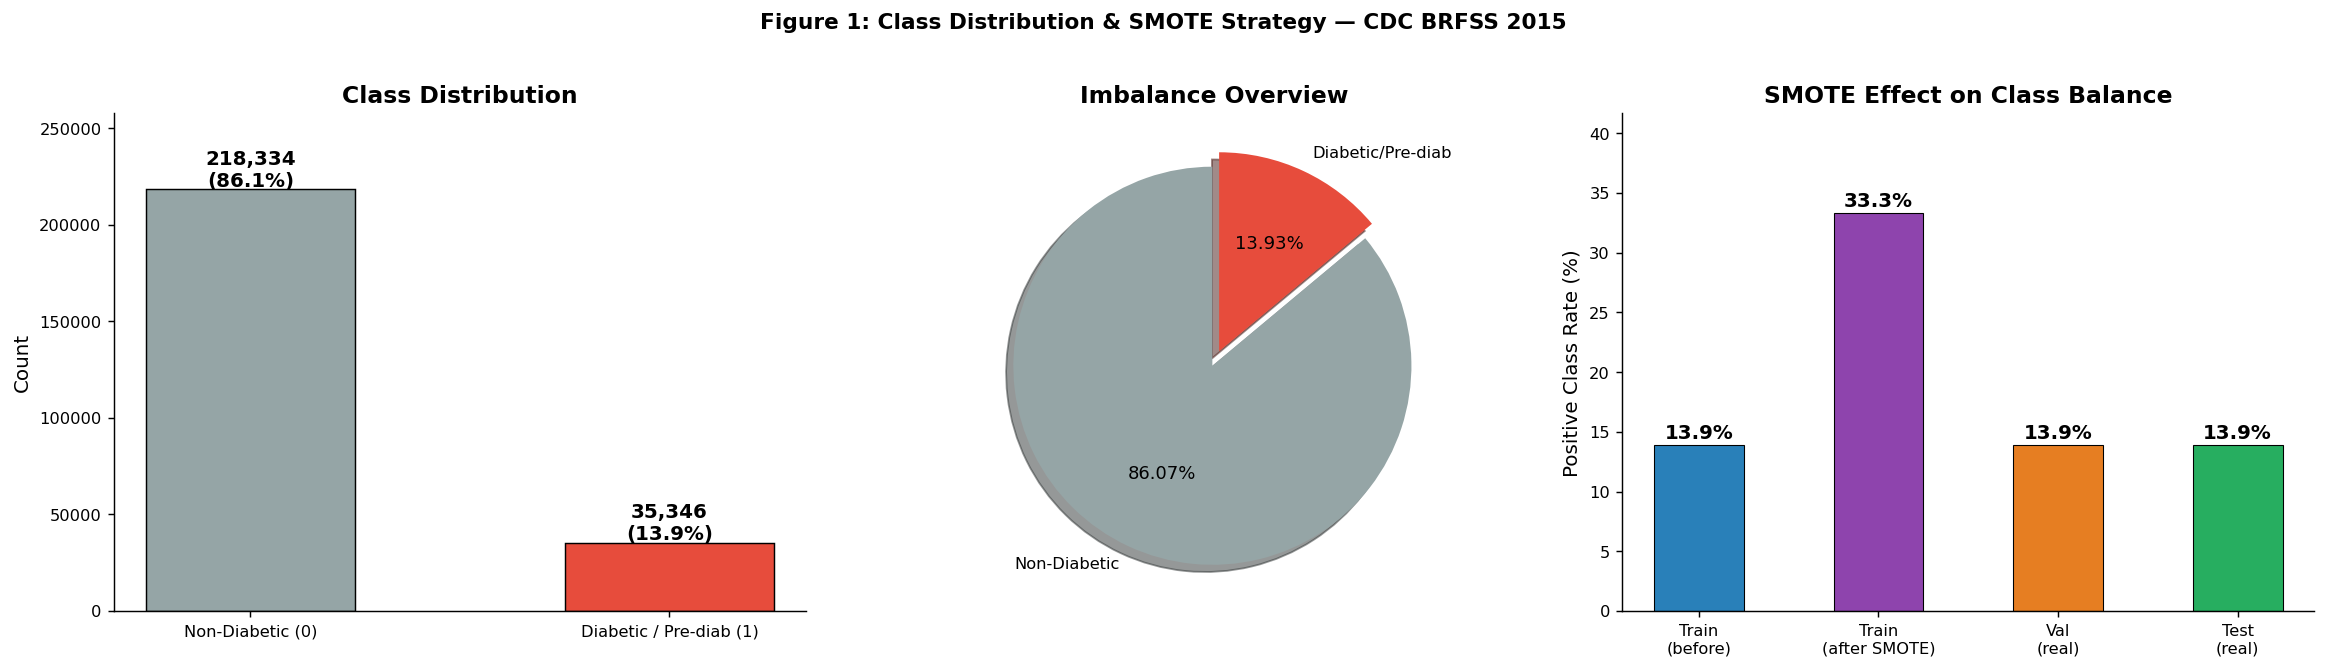

 SMOTE raises minority fraction from 13.9% → 33.3% in training only.
   Val and Test retain the real-world 13.9% — ensuring honest evaluation.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — Class distribution & summary stats
# ═══════════════════════════════════════════════════════════════
df_pos = df[df[TARGET_COL]==1]
df_neg = df[df[TARGET_COL]==0]

fig, axes = plt.subplots(1,3, figsize=(18,5))

# ── (a) Bar chart ─────────────────────────────────────────────
counts = [len(df_neg), len(df_pos)]
bars   = axes[0].bar(['Non-Diabetic (0)','Diabetic / Pre-diab (1)'],
                     counts, color=[C_NEG, C_POS],
                     edgecolor='black', lw=0.8, width=0.5)
for b,v in zip(bars,counts):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+1500,
                 f'{v:,}\n({v/N*100:.1f}%)', ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, max(counts)*1.18)
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution', fontweight='bold')

# ── (b) Pie ───────────────────────────────────────────────────
axes[1].pie(counts, labels=['Non-Diabetic','Diabetic/Pre-diab'],
            colors=[C_NEG,C_POS], autopct='%1.2f%%',
            startangle=90, explode=(0.02,0.06), shadow=True)
axes[1].set_title('Imbalance Overview', fontweight='bold')

# ── (c) SMOTE before/after ────────────────────────────────────
labels_ba  = ['Train\n(before)', 'Train\n(after SMOTE)', 'Val\n(real)', 'Test\n(real)']
pos_rates  = [
    y_train.mean()*100,
    y_train_sm.mean()*100,
    y_val.mean()*100,
    y_test.mean()*100
]
bar_colors = [C_TRAIN, '#8E44AD', C_VAL, C_TEST]
axes[2].bar(labels_ba, pos_rates, color=bar_colors, edgecolor='black', lw=0.6, width=0.5)
for i,(v,c) in enumerate(zip(pos_rates, bar_colors)):
    axes[2].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[2].set_ylabel('Positive Class Rate (%)')
axes[2].set_title('SMOTE Effect on Class Balance', fontweight='bold')
axes[2].set_ylim(0, max(pos_rates)*1.25)

plt.suptitle('Figure 1: Class Distribution & SMOTE Strategy — CDC BRFSS 2015',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(' SMOTE raises minority fraction from 13.9% → 33.3% in training only.')
print('   Val and Test retain the real-world 13.9% — ensuring honest evaluation.')

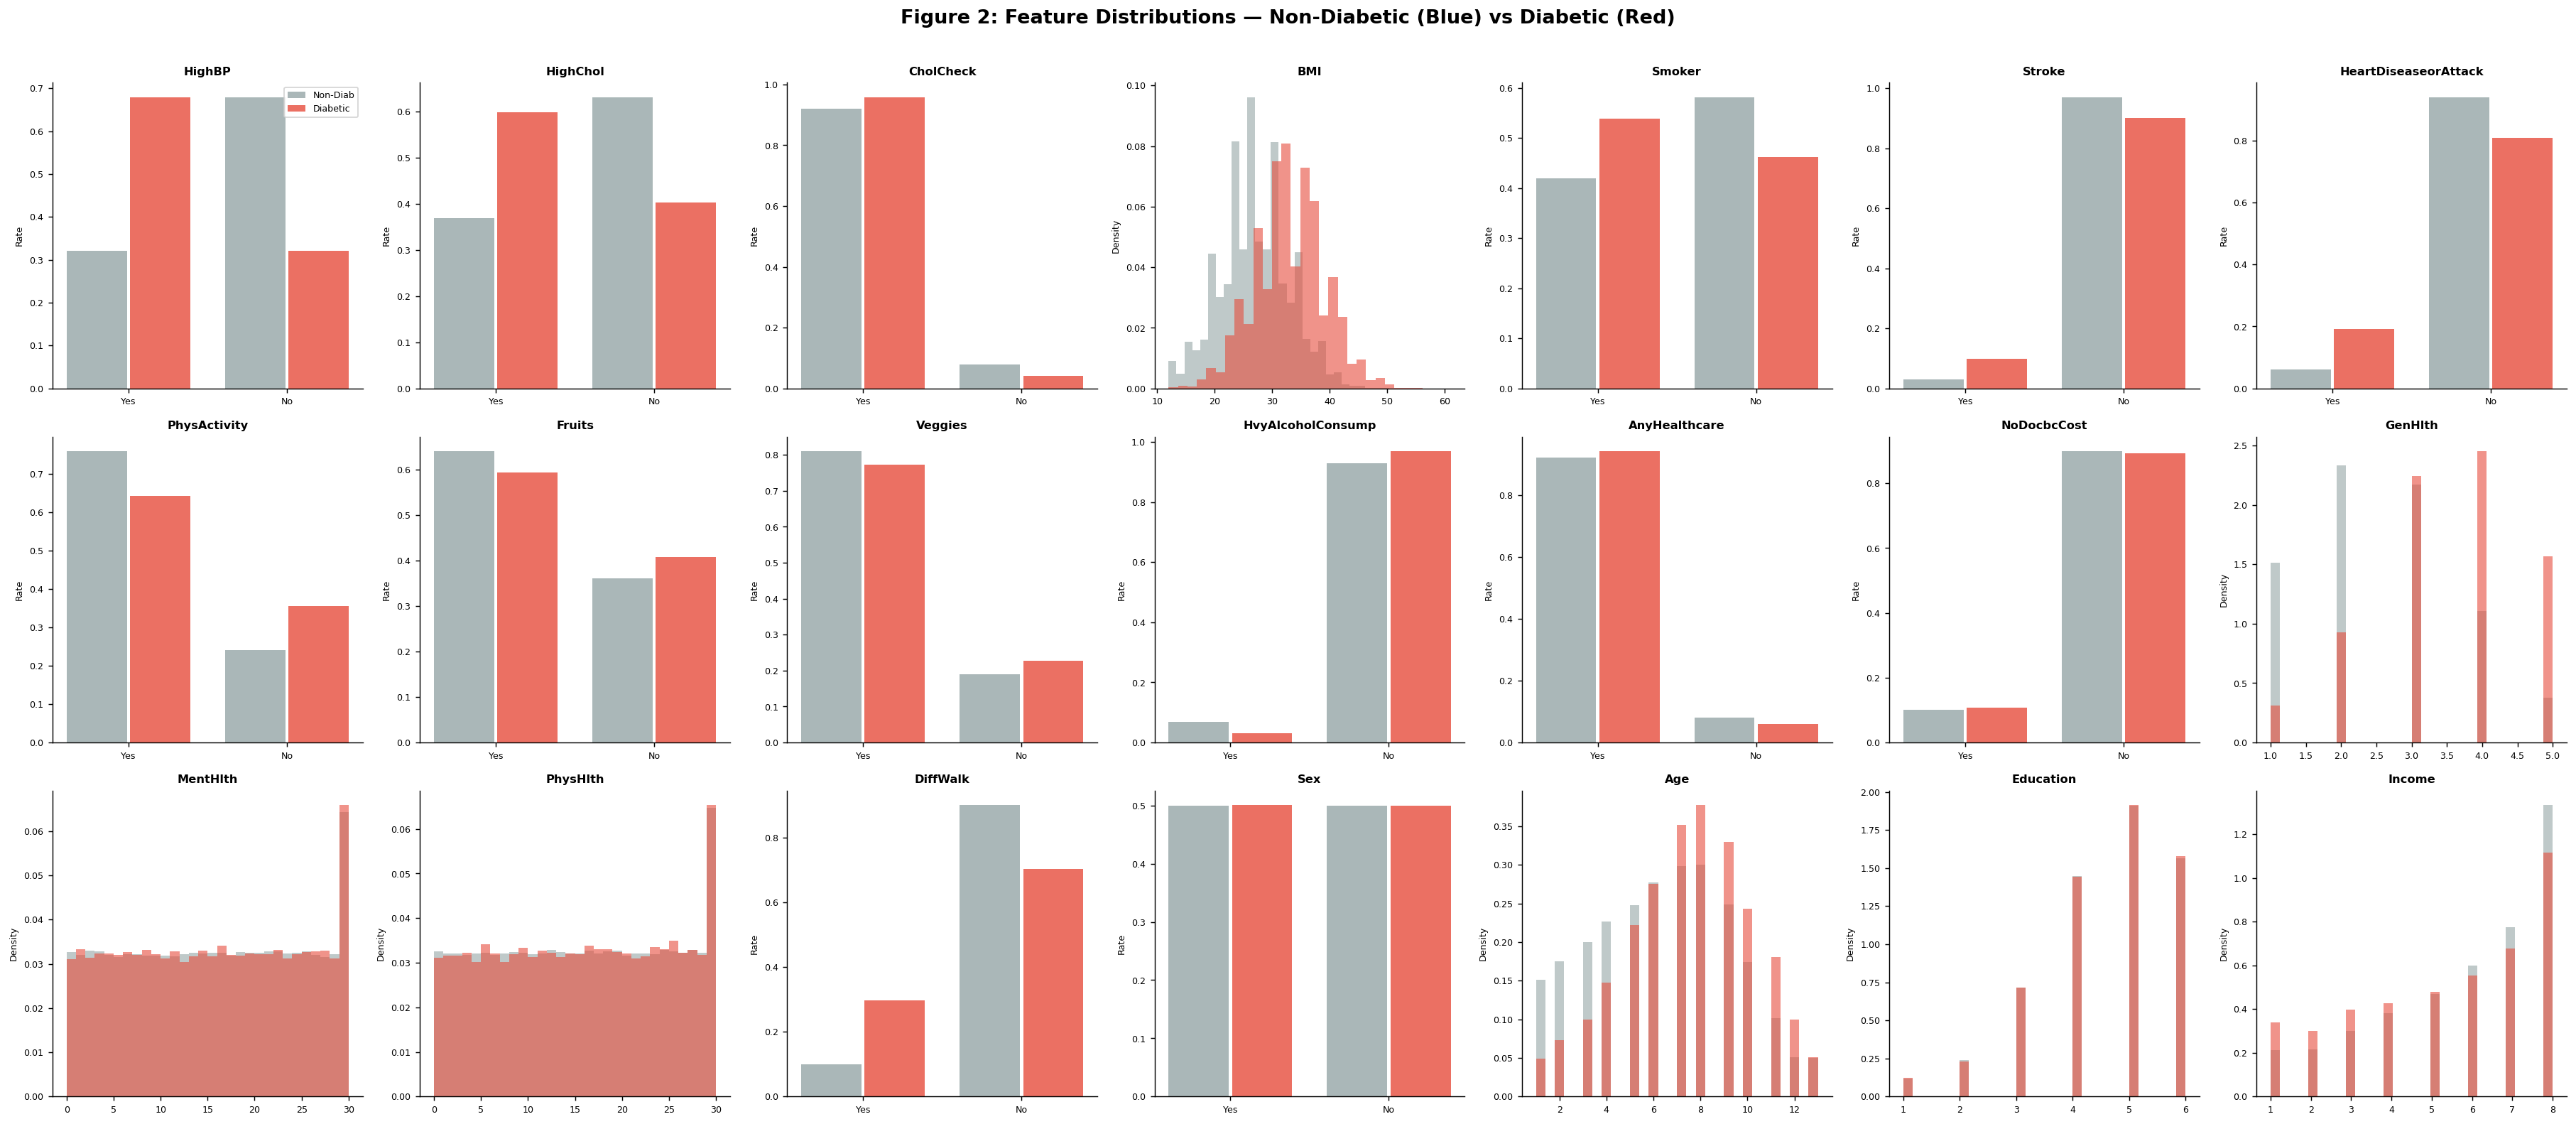

 KEY: GenHlth, BMI, Age, HighBP, DiffWalk show strongest class separation.
   Even HvyAlcohol is INVERSELY associated (healthy user bias) — a clinical insight.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — Feature distributions by class
# ═══════════════════════════════════════════════════════════════
CONT_FEATS = ['BMI','MentHlth','PhysHlth','GenHlth','Age','Education','Income']
BIN_FEATS  = [f for f in FEATURE_COLS if f not in CONT_FEATS]

fig, axes = plt.subplots(3, 7, figsize=(28, 12))
axes = axes.ravel()

for i, feat in enumerate(FEATURE_COLS):
    ax = axes[i]
    if feat in CONT_FEATS:
        ax.hist(df_neg[feat].values, bins=30, alpha=0.60,
                color=C_NEG, density=True, label='Non-Diab', linewidth=0)
        ax.hist(df_pos[feat].values, bins=30, alpha=0.60,
                color=C_POS, density=True, label='Diabetic', linewidth=0)
        ax.set_ylabel('Density', fontsize=7)
    else:
        x  = np.arange(2)
        ax.bar(x-0.2, [df_neg[feat].mean(), 1-df_neg[feat].mean()],
               0.38, color=C_NEG, alpha=0.80, label='Non-Diab')
        ax.bar(x+0.2, [df_pos[feat].mean(), 1-df_pos[feat].mean()],
               0.38, color=C_POS, alpha=0.80, label='Diabetic')
        ax.set_xticks([0,1]); ax.set_xticklabels(['Yes','No'], fontsize=7)
        ax.set_ylabel('Rate', fontsize=7)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
    if i == 0: ax.legend(fontsize=7)

plt.suptitle('Figure 2: Feature Distributions — Non-Diabetic (Blue) vs Diabetic (Red)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig2_feature_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print(' KEY: GenHlth, BMI, Age, HighBP, DiffWalk show strongest class separation.')
print('   Even HvyAlcohol is INVERSELY associated (healthy user bias) — a clinical insight.')

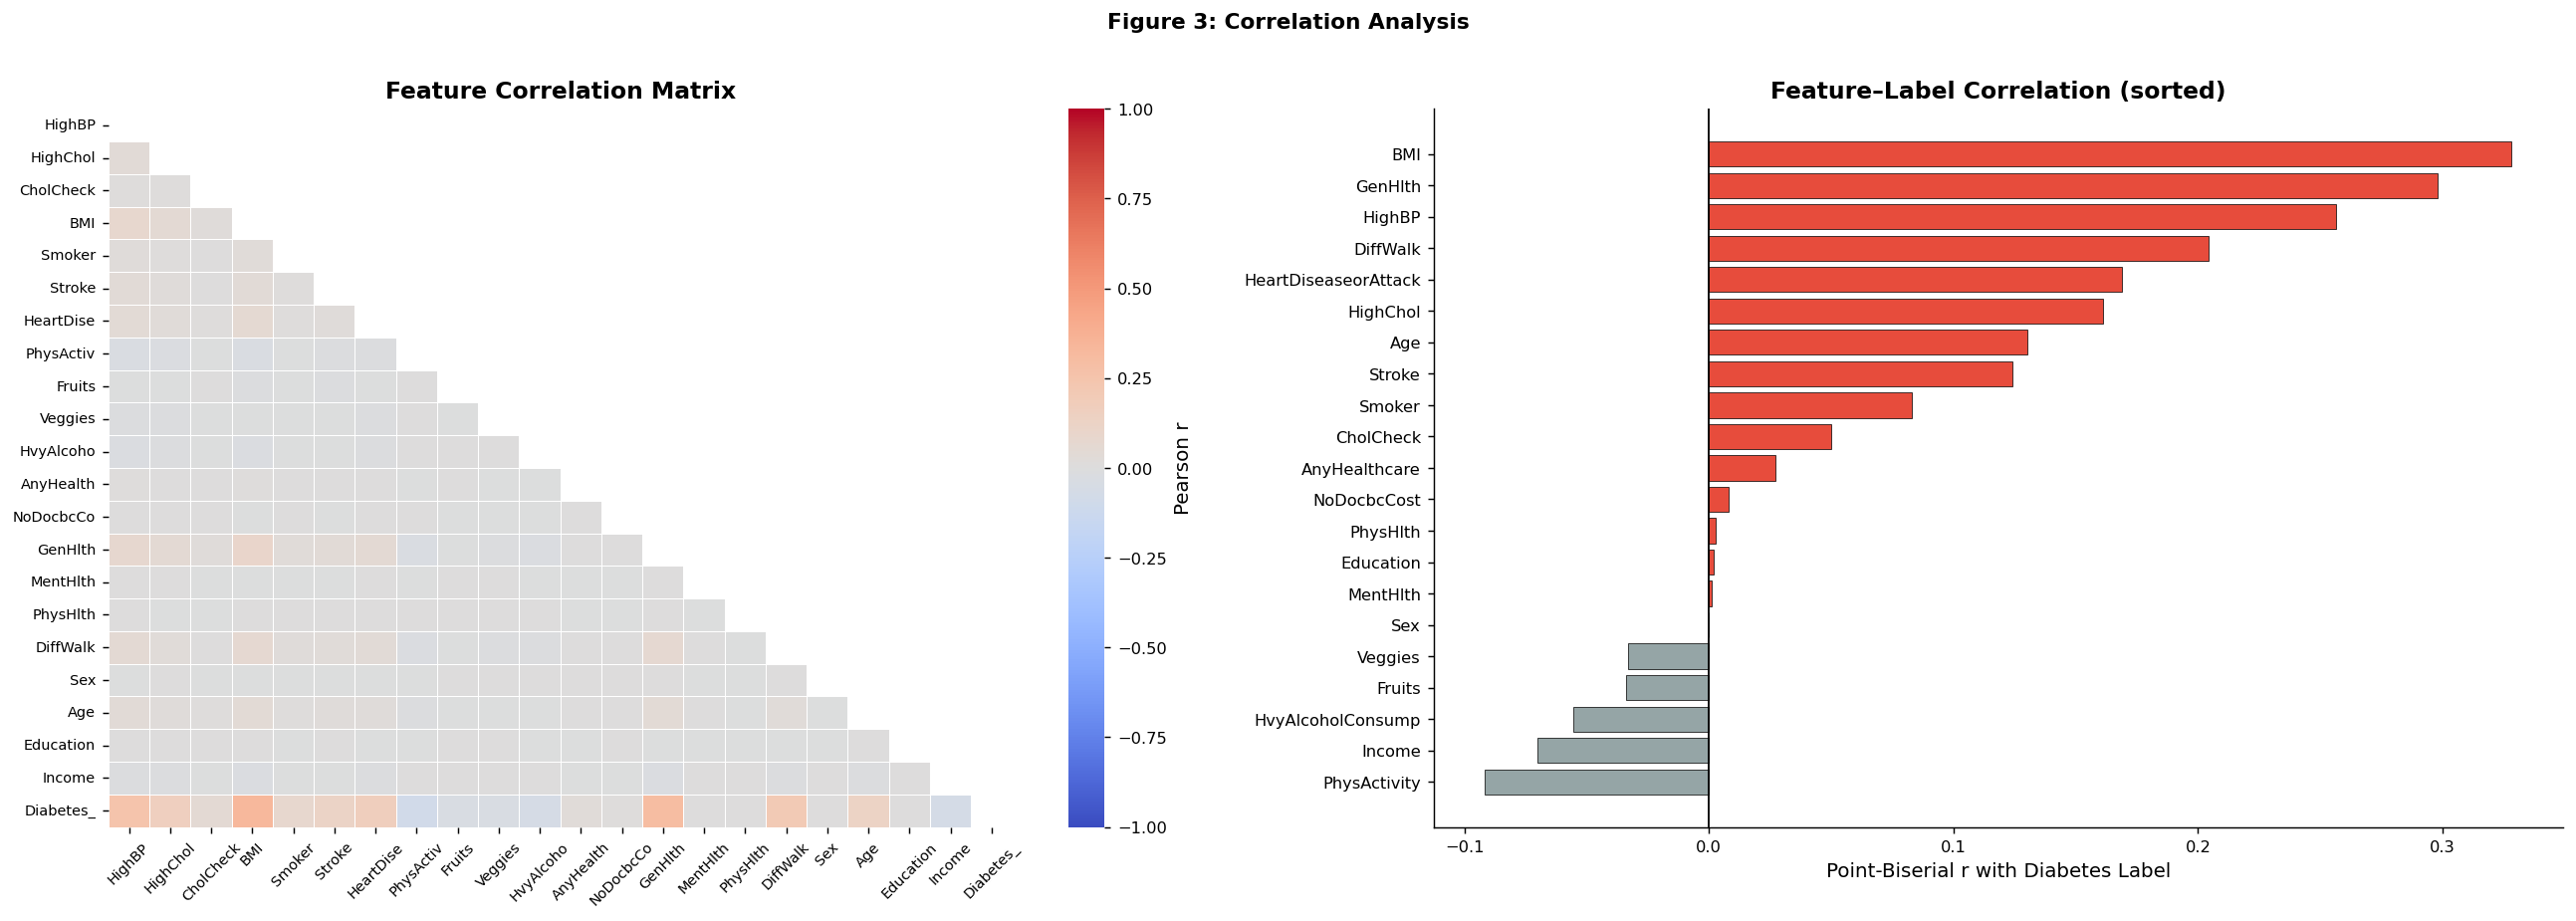

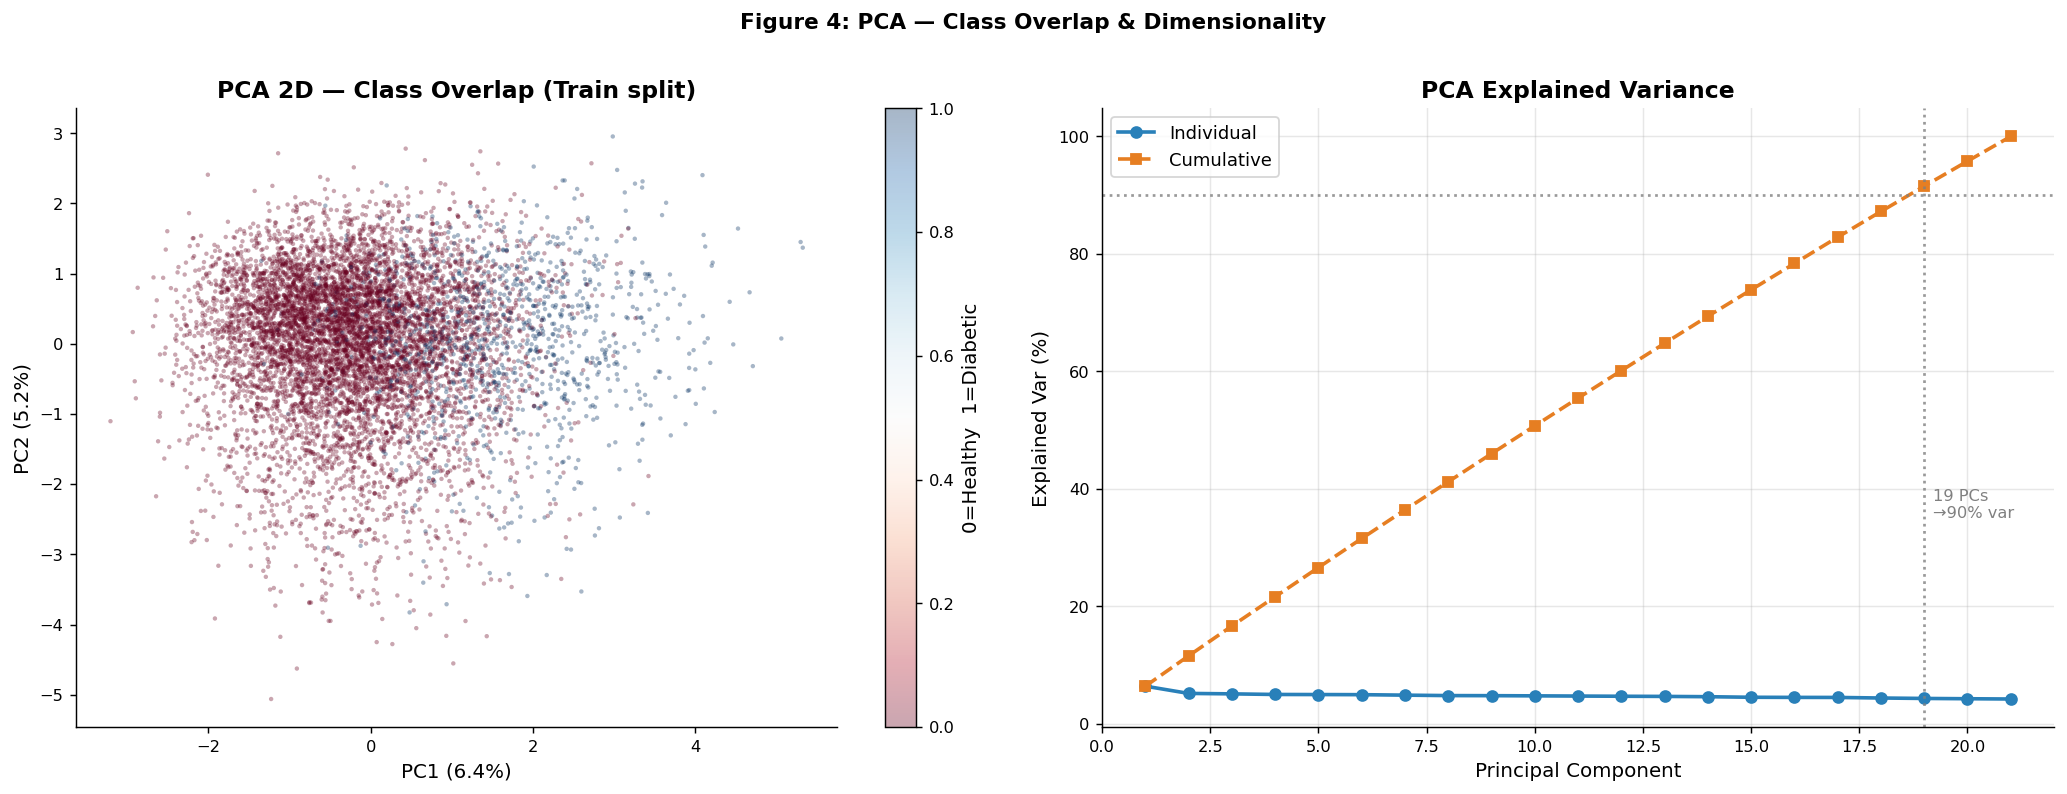

 Substantial overlap in PCA space → nonlinear deep model is essential.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 7 — Correlation + PCA
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# ── Pearson heatmap ───────────────────────────────────────────
corr = df[FEATURE_COLS+[TARGET_COL]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3, vmin=-1, vmax=1,
            xticklabels=[c[:9] for c in corr.columns],
            yticklabels=[c[:9] for c in corr.columns],
            cbar_kws={'label':'Pearson r'}, ax=axes[0])
axes[0].set_title('Feature Correlation Matrix', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

# ── Point-biserial vs target ──────────────────────────────────
pb = [pointbiserialr(df[TARGET_COL], df[f])[0] for f in FEATURE_COLS]
pb_df = pd.DataFrame({'f':FEATURE_COLS,'r':pb}).sort_values('r', ascending=True)
clrs  = [C_POS if v>0 else C_NEG for v in pb_df['r']]
axes[1].barh(pb_df['f'], pb_df['r'], color=clrs, edgecolor='black', lw=0.4)
axes[1].axvline(0, color='black', lw=1)
axes[1].set_xlabel('Point-Biserial r with Diabetes Label')
axes[1].set_title('Feature–Label Correlation (sorted)', fontweight='bold')

plt.suptitle('Figure 3: Correlation Analysis', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

# ── PCA ──────────────────────────────────────────────────────
idx_s   = np.random.choice(len(X_train_sc), 8000, replace=False)
pca_f   = PCA(); pca_f.fit(X_train_sc[idx_s])
pca_2   = PCA(n_components=2)
X_pca   = pca_2.fit_transform(X_train_sc[idx_s])
cum_var = np.cumsum(pca_f.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc = axes[0].scatter(X_pca[:,0], X_pca[:,1],
                     c=y_train[idx_s], cmap='RdBu', alpha=0.35, s=6, linewidths=0)
plt.colorbar(sc, ax=axes[0], label='0=Healthy  1=Diabetic')
axes[0].set_xlabel(f'PC1 ({pca_f.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_f.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PCA 2D — Class Overlap (Train split)', fontweight='bold')

comp_r = range(1, N_FEAT+1)
axes[1].plot(comp_r, pca_f.explained_variance_ratio_*100,
             'o-', color=C_TRAIN, lw=2, label='Individual')
axes[1].plot(comp_r, cum_var*100,
             's--', color=C_VAL,   lw=2, label='Cumulative')
n90 = int(np.argmax(cum_var>=0.90))+1
axes[1].axvline(n90, color='gray', ls=':', alpha=0.8)
axes[1].axhline(90,  color='gray', ls=':', alpha=0.8)
axes[1].text(n90+0.2, 35, f'{n90} PCs\n→90% var', fontsize=9, color='gray')
axes[1].set_xlabel('Principal Component'); axes[1].set_ylabel('Explained Var (%)')
axes[1].set_title('PCA Explained Variance', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Figure 4: PCA — Class Overlap & Dimensionality', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig4_pca.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Substantial overlap in PCA space → nonlinear deep model is essential.')

---

[Next: Residual MLP & Depth × Width Ablation →](02_model_and_depth_width_ablation.ipynb)